# Coregistrazione di due immagini
Il seguente notebook ha lo scopo di spiegare il processo seguito per la coregistrazione di due immagini, una immagine label free (non colorata) e una immagine stained (colorata). Questo step è necessario per eseguire l'allenamento di una rete neurale supervisionata.

## Passaggi 
### Pacchetti necessari
I pacchetti necessari all'avvio del notebook sono:

- OpenCV → `cv2`: scaricabile con `pip install opencv-python`

- NumPy → `numpy`: scaricabile con `pip install numpy`

- Matplotlib → `matplotlib`: scaricabile con `pip install matplotlib`

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Normalizzazione
Gli algoritmi di **_Feature Matching_** individuano i _keypoint_ principalmente in zone ad alto contrasto, poiché queste aree presentano variazioni di intensità più marcate. Per questo motivo, una normalizzazione del contrasto può facilitare l’individuazione e la distinzione delle caratteristiche tra immagini diverse.

**Nota bene**: _un keypoint è un punto caratteristico dell’immagine, tipicamente situato in regioni con forti variazioni di intensità (come angoli, bordi, ecc.), rilevato dagli algoritmi di feature detection per consentire il confronto tra immagini._

Se l’istogramma dell’immagine è sbilanciato, ad esempio concentrato verso i toni scuri (neri) o chiari (bianchi), la rilevazione dei keypoint può risultare compromessa, riducendo l'efficacia del matching tra le immagini. Di conseguenza valutato vari metodi di normalizzazione delle immagini per ottenere istogrammi più uniformi. Di seguito riportiamo un grafico che presenta l'istogramma dell'immagine originale (_label free_), e le sue varianti normalizzate utilizzando i metodi:

- `cv2.equalizeHist(label_free)`

- `cv2.normalize(label_free, None, 0, 255, cv2.NORM_MINMAX)`

- `cv2.createCLAHE(clipLimit=2.0, tileSize=(8, 8))`

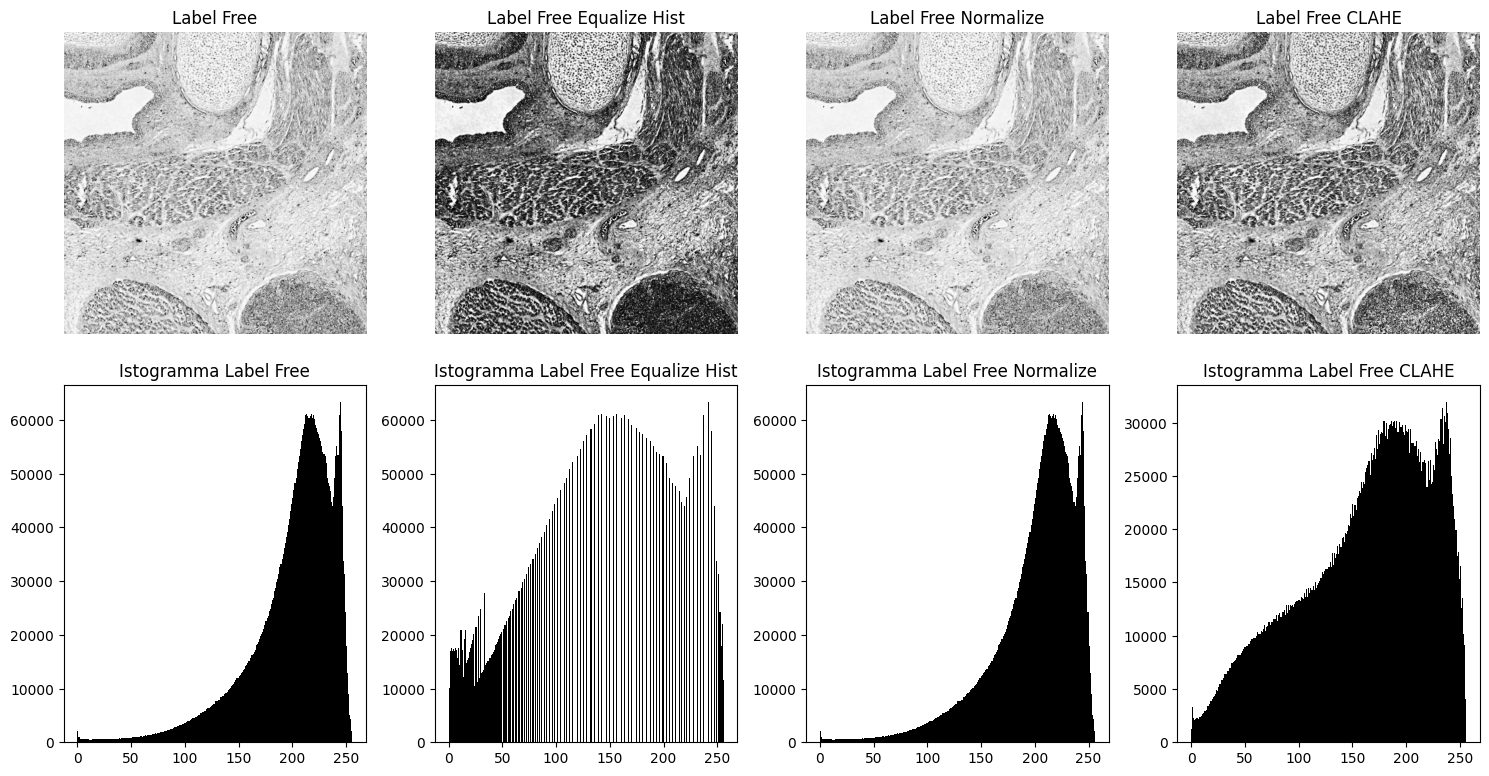

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Caricamento l'immagine
label_free = cv2.cvtColor(cv2.imread("../Materiale/Immagini/label_free_0.png"), cv2.COLOR_BGR2GRAY)

# Normalizzazioni
lf_equalizeHist = cv2.equalizeHist(label_free)
lf_normalize = cv2.normalize(label_free, None, 0, 255, cv2.NORM_MINMAX)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
lf_clahe = clahe.apply(label_free)

# Visualizzazione le immagini
figure, subplots = plt.subplots(2, 4, figsize=(15, 8))
subplots[0, 0].imshow(label_free, cmap='gray')
subplots[0, 0].set_title("Label Free")
subplots[0, 0].axis('off')
subplots[0, 1].imshow(lf_equalizeHist, cmap='gray')
subplots[0, 1].set_title("Label Free Equalize Hist")
subplots[0, 1].axis('off')
subplots[0, 2].imshow(lf_normalize, cmap='gray')
subplots[0, 2].set_title("Label Free Normalize")
subplots[0, 2].axis('off')
subplots[0, 3].imshow(lf_clahe, cmap='gray')
subplots[0, 3].set_title("Label Free CLAHE")
subplots[0, 3].axis('off')

subplots[1, 0].hist(label_free.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 0].set_title("Istogramma Label Free")
subplots[1, 1].hist(lf_equalizeHist.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 1].set_title("Istogramma Label Free Equalize Hist")
subplots[1, 2].hist(lf_normalize.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 2].set_title("Istogramma Label Free Normalize")
subplots[1, 3].hist(lf_clahe.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 3].set_title("Istogramma Label Free CLAHE")
plt.tight_layout()
plt.show()

Dal grafico si evince come l'istogramma ottenuto tramite CLAHE sia il migliore, ma ancora non ottimale. Variando i parametri della funzione CLAHE otteniamo un istogramma idoneo al nostro fine.

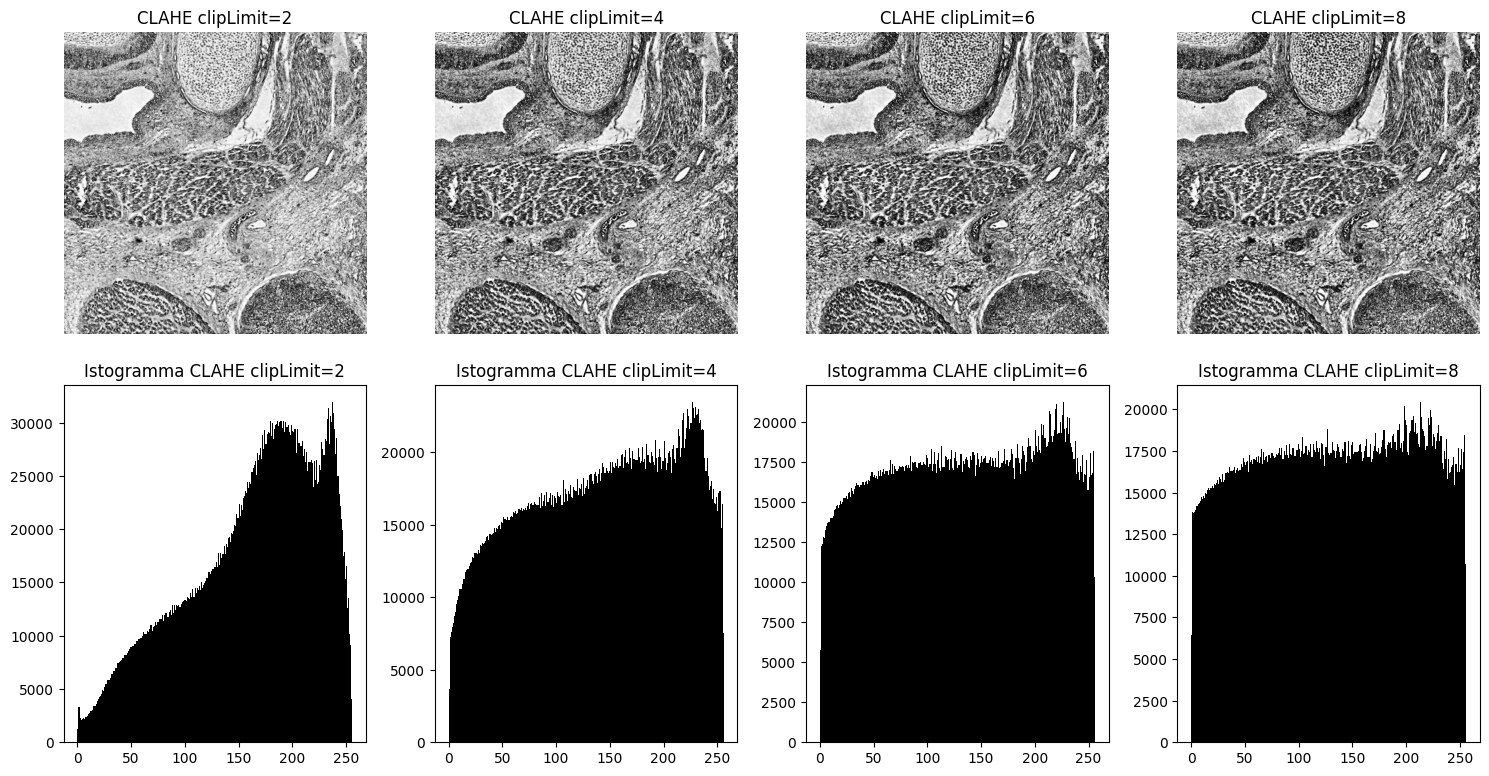

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Caricamento l'immagine
label_free = cv2.cvtColor(cv2.imread("../Materiale/Immagini/label_free_0.png"), cv2.COLOR_BGR2GRAY)

# Normalizzazioni
lf_clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(label_free)
lf_clahe_4 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8)).apply(label_free)
lf_clahe_6 = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8, 8)).apply(label_free)
lf_clahe_8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8)).apply(label_free)

# Visualizzazione le immagini
figure, subplots = plt.subplots(2, 4, figsize=(15, 8))
subplots[0, 0].imshow(lf_clahe_2, cmap='gray')
subplots[0, 0].set_title("CLAHE clipLimit=2")
subplots[0, 0].axis('off')
subplots[0, 1].imshow(lf_clahe_4, cmap='gray')
subplots[0, 1].set_title("CLAHE clipLimit=4")
subplots[0, 1].axis('off')
subplots[0, 2].imshow(lf_clahe_6, cmap='gray')
subplots[0, 2].set_title("CLAHE clipLimit=6")
subplots[0, 2].axis('off')
subplots[0, 3].imshow(lf_clahe_8, cmap='gray')
subplots[0, 3].set_title("CLAHE clipLimit=8")
subplots[0, 3].axis('off')

subplots[1, 0].hist(lf_clahe_2.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 0].set_title("Istogramma CLAHE clipLimit=2")
subplots[1, 1].hist(lf_clahe_4.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 1].set_title("Istogramma CLAHE clipLimit=4")
subplots[1, 2].hist(lf_clahe_6.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 2].set_title("Istogramma CLAHE clipLimit=6")
subplots[1, 3].hist(lf_clahe_8.ravel(), bins=256, range=(0, 256), color='black')
subplots[1, 3].set_title("Istogramma CLAHE clipLimit=8")
plt.tight_layout()
plt.show()

Notiamo come l'incremento del parametro `clipLimit` porti a un istogramma sempre più omogenei. Sperimentalmente abbiamo individuato come valore ottimale per il rilevamento di _keypoints_ **18**.

**Nota bene**: _La conversione in scala di grigi e la successiva normalizzazione delle immagini viene applicata a una copia di esse e viene utilizzata solo per l'individuazione dei keypoints. La coregistrazione, che utilizza questi ultimi, viene applicata sulle immagini originali._

## Maschere
Ottenute le immagini normalizzate, potremmo passare alla fase di individuazione dei _keypoints_, e quindi all'allineamento. Nonostante ciò, preferiamo includere all'interno della pipeline una fase dedicata alla creazione di maschere che ci permettono di individuare le zone di ricerca di _keypoints_ valide, separando lo sfondo (e di conseguenza gli artefatti dovuti alla normalizzazione presenti in esso) dalla cellula.

La creazione delle maschere avviene secondo i seguenti passaggi:

1. Binarizzazione con un _threshold_ ottenuto empiricamente (variabile a seconda dell'immagine);

2. Individuazione di regioni di pixel contigui all'interno dell'immagine binarizzata;

3. Filtraggio delle 10 regioni più grandi tramite deviazione standard calcolata sull'immagine originale*;

4. Aggiunta delle regioni filtrate alla maschera;

_\*La deviazione standard viene utilizzata per individuare quali regioni fanno effettivamente parte dello sfondo: una deviazione standard ridotta è indice di uniformità tra i valori dei pixel. Lo sfondo, essendo uniforme di natura, avrà una deviazione standard molto bassa; le parti di cellula erronamente individuate come sfondo, invece, presenteranno colori non uniformi, e di conseguenza una deviazione standard maggiore._

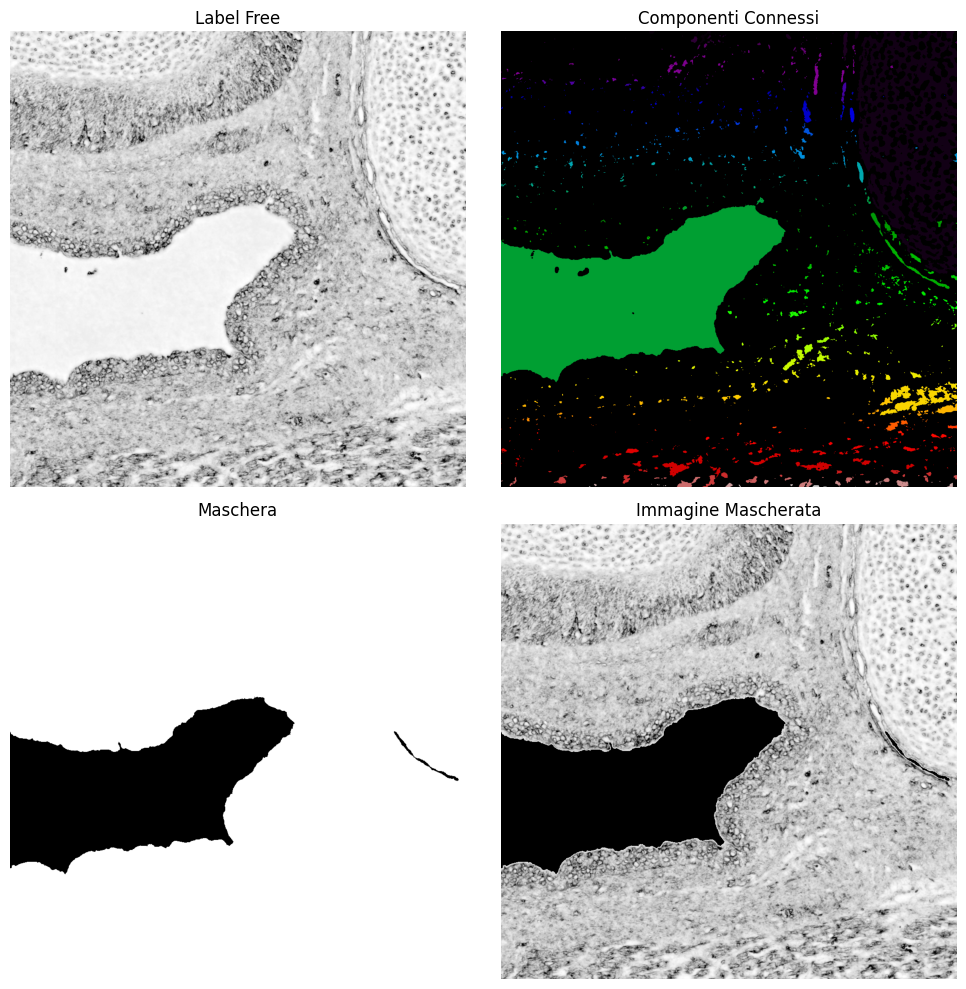

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Caricamento l'immagine
label_free = cv2.cvtColor(cv2.imread("../Materiale/Immagini/label_free_0.png"), cv2.COLOR_BGR2GRAY)[0:1000, 0:1000]

# Binarizzazione
_, binary = cv2.threshold(label_free, 230, 255, cv2.THRESH_BINARY)
# Individuazione dei componenti connessi
_, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

# Ordinamento in modo decrescente dei componenti per area
n_filtered = 10
sorted_indices = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1] + 1

# Crea una maschera vuota per filtrare i componenti
lf_mask = np.zeros_like(binary).astype(np.uint8)

# Per ogni componente in ordine decrescente di area
for i in sorted_indices[:n_filtered]:
    x, y, w, h, area = stats[i]

    # Filtra i componenti troppo piccoli
    if w < 100 and h < 100:
        continue

    # Riempe la maschera
    component_mask = (labels == i).astype(np.uint8) * 255
    countours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(component_mask, countours, -1, 255, thickness=cv2.FILLED)
    
    # Estrae dalla regione di interesse
    roi = label_free[y:y+h, x:x+w]
    roi_mask = component_mask[y:y+h, x:x+w]

    # Calcola la deviazione standard della regione di interesse
    std_dev = cv2.meanStdDev(roi, mask=roi_mask)[1][0, 0]

    # Filtra i componenti con una deviazione standard troppo alta
    if std_dev < 8:
        lf_mask[component_mask == 255] = 255

# Inverte la maschera per ottenere il foreground
# La maschera vale 255 per il foreground e 0 per lo sfondo
lf_mask = cv2.bitwise_not(lf_mask)

masked_image = cv2.bitwise_and(label_free, label_free, mask=lf_mask)

# Visualizzazione della maschera
figure, subplots = plt.subplots(2, 2, figsize=(10, 10))
subplots[0, 0].imshow(label_free, cmap='gray')
subplots[0, 0].set_title("Label Free")
subplots[0, 0].axis('off')
subplots[0, 1].imshow(labels, cmap='nipy_spectral')
subplots[0, 1].set_title("Componenti Connessi")
subplots[0, 1].axis('off')
subplots[1, 0].imshow(lf_mask, cmap='gray')
subplots[1, 0].set_title("Maschera")
subplots[1, 0].axis('off')
subplots[1, 1].imshow(masked_image, cmap='gray')
subplots[1, 1].set_title("Immagine Mascherata")
subplots[1, 1].axis('off')
plt.tight_layout()
plt.show()

_I grafici e i valori utilizzati sono a scopo illustrativo._

## Algoritmi di allineamento
Gli algoritmi SIFT (Scale-Invariant Feature Transform) e ORB (Oriented FAST and Rotated BRIEF) si basano sul principio di rilevamento di feature locali (_keypoints_) e calcolano descrittori che consentono di confrontarle tra immagini diverse.

SIFT rileva keypoint a diverse scale e orientamenti, calcolando per ciascuno un descrittore basato su istogrammi di gradienti. È particolarmente efficace in presenza di rotazioni, cambi di scala e variazioni di illuminazione, ma è computazionalmente più costoso.

ORB, invece, è un algoritmo più leggero e veloce, basato su FAST per la rilevazione dei _keypoints_ e BRIEF per la descrizione. Sebbene sia meno preciso in scenari complessi rispetto a SIFT, è adatto a contesti real-time grazie alla sua efficienza e leggerezza computazionale.

Dopo fasi di sperimentazione su entrambi i metodi, abbiamo valutato SIFT come migliore tra i due, e deciso di utilizzare quest'ultimo all'interno del progetto. Tale scelta è dovuta a una preferenza sulla precisione dei risultati, piuttosto che dal costo computazionale.

I due algoritmi si inizializzano nel seguente modo:

SIFT - Numero di match: 2150
ORB - Numero di match: 2596


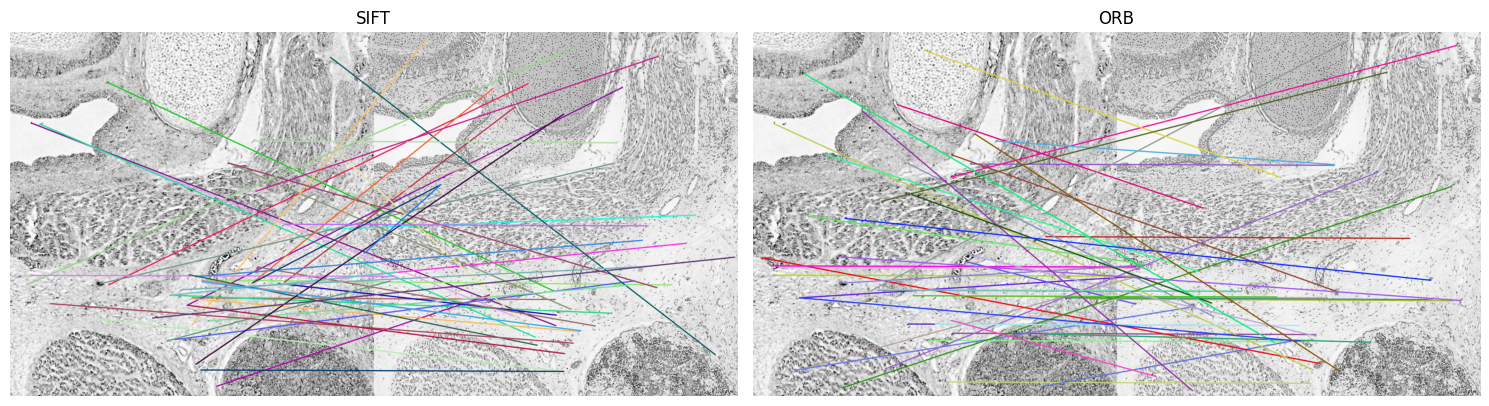

In [2]:
import cv2
import matplotlib.pyplot as plt

# Caricamento delle immagini
label_free = cv2.cvtColor(cv2.imread("../Materiale/Immagini/label_free_0.png"), cv2.COLOR_BGR2GRAY)
stained = cv2.cvtColor(cv2.imread("../Materiale/Immagini/stained_0.png"), cv2.COLOR_BGR2GRAY)

# Calcolo delle features con SIFT
sift = cv2.SIFT_create(nfeatures=10000)
keypoints_1_sift, descriptors_1_sift = sift.detectAndCompute(label_free, None)
keypoints_2_sift, descriptors_2_sift = sift.detectAndCompute(stained, None)

# Calcolo delle features con ORB
orb = cv2.ORB_create(nfeatures=10000)
keypoints_1_orb, descriptors_1_orb = orb.detectAndCompute(label_free, None)
keypoints_2_orb, descriptors_2_orb = orb.detectAndCompute(stained, None)

# Matching delle features calcolate con SIFT
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches_sift = bf.match(descriptors_1_sift, descriptors_2_sift)
matches_sift = sorted(matches_sift, key=lambda x: x.distance)
print(f"SIFT - Numero di match: {len(matches_sift)}")

# Matching delle features calcolate con ORB
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf.match(descriptors_1_orb, descriptors_2_orb)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)
print(f"ORB - Numero di match: {len(matches_orb)}")

# Visualizzazione dei risultati
figure, subplots = plt.subplots(1, 2, figsize=(15, 10))
subplots[0].imshow(cv2.drawMatches(label_free, keypoints_1_sift, stained, keypoints_2_sift, matches_sift[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchesThickness=5))
subplots[0].set_title("SIFT")
subplots[0].axis('off')
subplots[1].imshow(cv2.drawMatches(label_free, keypoints_1_orb, stained, keypoints_2_orb, matches_orb[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchesThickness=5))
subplots[1].set_title("ORB")
subplots[1].axis('off')
plt.tight_layout()
plt.show()

## Filtri
Dopo aver individuato le corrispondenze tra i punti chiave di due immagini, è fondamentale filtrare i match meno affidabili per evitare che influenzino negativamente la stima della trasformazione geometrica. Tra i metodi più comuni si trovano il Lowe's Ratio test e il filtraggio basato su distanza euclidea.

Il Lowe's Ratio test confronta la distanza del miglior match con quella del secondo migliore: un match viene accettato solo se il primo è significativamente più simile del secondo, riducendo il rischio di ambiguità. Questo approccio è particolarmente efficace quando si lavora con descrittori densi e scene complesse.

Nel nostro caso, tuttavia, si è optato per un filtro basato sulla distanza euclidea tra i _keypoints_. Dopo l'accoppiamento tra descrittori, viene calcolata la distanza geometrica tra le coordinate dei punti corrispondenti, e vengono mantenuti solo quelli entro una soglia predefinita, basata sull'allinemento originale delle immagini. Questa scelta è motivata dal fatto che, nell'ambito delle immagini istopatologiche, i tessuti da allineare presentano una struttura relativamente simile, e ci si aspetta una trasformazione coerente e contenuta. Pertanto, la distanza spaziale è un filtro efficace e facilmente interpretabile per eliminare corrispondenze errate.

Un ulteriore motivo per non utilizzare il Lowe's Ratio test è l'efficacia del parametro `crossCheck=True` nel `BFMatcher`, che a confronto risulta più rigoroso, restituendo meno match ma più affidabili.

SIFT - Numero di match iniziali: 2150
SIFT - Numero di match filtrati: 180
ORB - Numero di match iniziali: 2596
ORB - Numero di match filtrati: 259


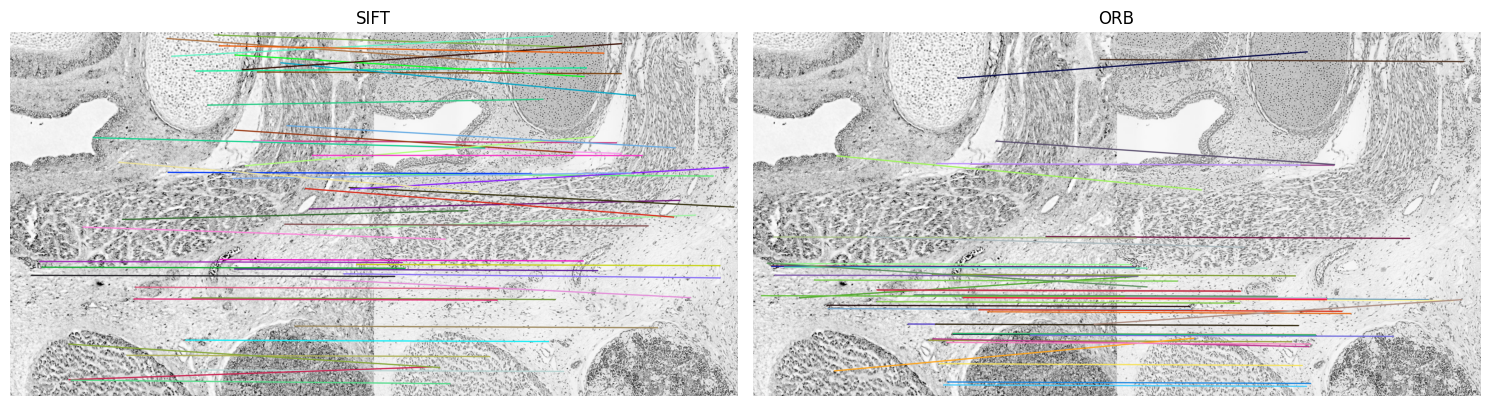

'\nSIFT - Numero di match: 3108\nORB - Numero di match: 2596\nSIFT - Numero di match iniziali: 3108\nSIFT - Numero di match filtrati: 136\nORB - Numero di match iniziali: 2596\nORB - Numero di match filtrati: 259\n'

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Caricamento delle immagini
label_free = cv2.cvtColor(cv2.imread("../Materiale/Immagini/label_free_0.png"), cv2.COLOR_BGR2GRAY)
stained = cv2.cvtColor(cv2.imread("../Materiale/Immagini/stained_0.png"), cv2.COLOR_BGR2GRAY)

# Calcolo delle features con SIFT
sift = cv2.SIFT_create(nfeatures=10000)
keypoints_1_sift, descriptors_1_sift = sift.detectAndCompute(label_free, None)
keypoints_2_sift, descriptors_2_sift = sift.detectAndCompute(stained, None)

# Calcolo delle features con ORB
orb = cv2.ORB_create(nfeatures=10000)
keypoints_1_orb, descriptors_1_orb = orb.detectAndCompute(label_free, None)
keypoints_2_orb, descriptors_2_orb = orb.detectAndCompute(stained, None)

# Matching delle features calcolate con SIFT
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches_sift = bf.match(descriptors_1_sift, descriptors_2_sift)

# Filtraggio dei match con distanza euclidea
filtered_matches_sift = []
for match in matches_sift:
    distance = np.linalg.norm(np.array(keypoints_1_sift[match.queryIdx].pt) - np.array(keypoints_2_sift[match.trainIdx].pt))
    if distance <= 200:
        filtered_matches_sift.append(match)
filtered_matches_sift = sorted(filtered_matches_sift, key=lambda x: x.distance)

print(f"SIFT - Numero di match iniziali: {len(matches_sift)}")
print(f"SIFT - Numero di match filtrati: {len(filtered_matches_sift)}")

# Matching delle features calcolate con ORB
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf.match(descriptors_1_orb, descriptors_2_orb)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)

# Filtraggio dei match con distanza euclidea
filtered_matches_orb = []
for match in matches_orb:
    distance = np.linalg.norm(np.array(keypoints_1_orb[match.queryIdx].pt) - np.array(keypoints_2_orb[match.trainIdx].pt))
    if distance <= 200:
        filtered_matches_orb.append(match)
filtered_matches_orb = sorted(filtered_matches_orb, key=lambda x: x.distance)

print(f"ORB - Numero di match iniziali: {len(matches_orb)}")
print(f"ORB - Numero di match filtrati: {len(filtered_matches_orb)}")

# Visualizzazione dei risultati
figure, subplots = plt.subplots(1, 2, figsize=(15, 10))
subplots[0].imshow(cv2.drawMatches(label_free, keypoints_1_sift, stained, keypoints_2_sift, filtered_matches_sift[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchesThickness=5))
subplots[0].set_title("SIFT")
subplots[0].axis('off')
subplots[1].imshow(cv2.drawMatches(label_free, keypoints_1_orb, stained, keypoints_2_orb, filtered_matches_orb[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchesThickness=5))
subplots[1].set_title("ORB")
subplots[1].axis('off')
plt.tight_layout()
plt.show()

"""
SIFT - Numero di match: 3108
ORB - Numero di match: 2596
SIFT - Numero di match iniziali: 3108
SIFT - Numero di match filtrati: 136
ORB - Numero di match iniziali: 2596
ORB - Numero di match filtrati: 259
"""

_Il codice presentato è a scopo illustrativo e presenta variabili e valori indicativi._

I _keypoints_ sono stati calcolati sulle immagini senza normalizzazione per scopi illustrativi. Nel codice reale i _keypoints_ vengono calcolati sulle immagini normalizzate con CLAHE.

## Allineamento
Per la coregistrazione delle immagini, abbiamo quindi scelto di utilizzare SIFT con il filtro basato sulla distanza euclidea, utilizzando le maschere per individuare i punti di ricerca dei _keypoints_.

Una volta trovate le corrispondenze tra punti chiave nelle due immagini, è possibile stimare una trasformazione geometrica (es. omografica o affine) che consente di allinearle. Per fare ciò possiamo utilizzare 3 alternative proposte da **OpenCV**:

1. `cv2.estimateAffinePartial2D`: presenta 4 gradi di libertà (traslazione orizzontale e verticale, rotazione, scala uniforme), mantiene forme, angoli e proporzioni;

2. `cv2.estimateAffine2D`: presenta 6 gradi di libertà (traslazione orizzontale e verticale, rotazione, scala orizzontale e verticale, shear), mantiene parallelismo;

3. `cv2.findHomography`: presenta 8 gradi di libertà (traslazione orizzontale e verticale, rotazione, scala orizzontale e verticale, shear, alterazione prospettica orizzontale e verticale); 


Data la natura delle nostre immagini, e dato che non vogliamo alterazioni prospettiche o non uniformi, è sufficiente utilizzare la funzione `cv2.estimateAffinePartial2D`. La matrice omografica calcolata viene poi applicata utilizzando la funzione `cv2.warpAffine`.

Numero di match iniziali: 3221
Numero di match filtrati: 416


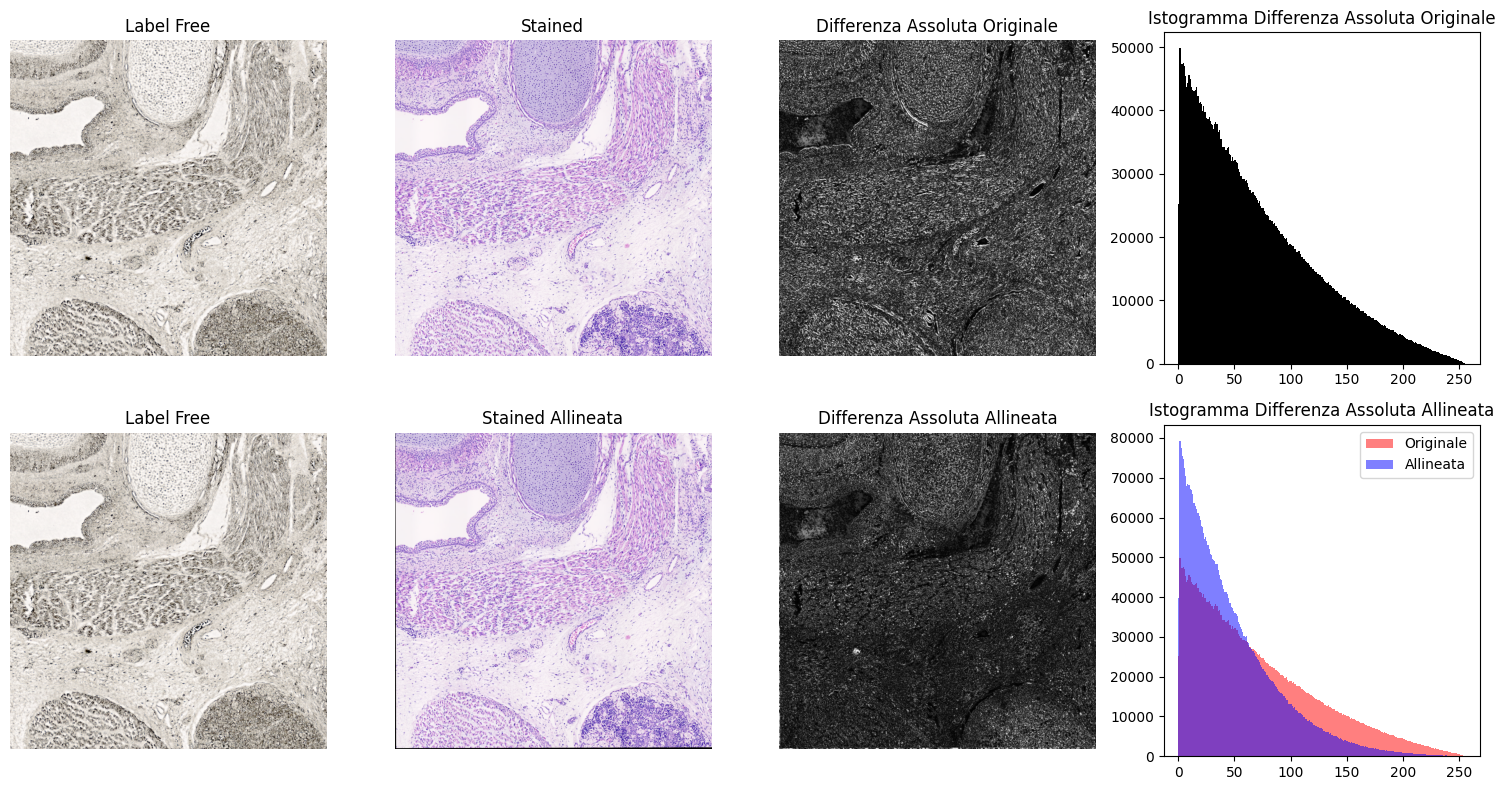

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Caricamento delle immagini
label_free = cv2.imread("../Materiale/Immagini/label_free_0.png")
stained = cv2.imread("../Materiale/Immagini/stained_0.png")

# Calcolo delle maschere
_, binary = cv2.threshold(cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY), 230, 255, cv2.THRESH_BINARY)
_, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
sorted_indices = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1] + 1
lf_mask = np.zeros_like(binary).astype(np.uint8)
for i in sorted_indices[:10]:
    x, y, w, h, area = stats[i]
    if w < 100 and h < 100:
        continue
    component_mask = (labels == i).astype(np.uint8) * 255
    countours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(component_mask, countours, -1, 255, thickness=cv2.FILLED)
    roi = label_free[y:y+h, x:x+w]
    roi_mask = component_mask[y:y+h, x:x+w]
    std_dev = cv2.meanStdDev(roi, mask=roi_mask)[1][0, 0]
    if std_dev < 10:
        lf_mask[component_mask == 255] = 255
lf_mask = cv2.bitwise_not(lf_mask)

_, binary = cv2.threshold(cv2.cvtColor(stained, cv2.COLOR_BGR2GRAY), 230, 255, cv2.THRESH_BINARY)
_, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
sorted_indices = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1] + 1
st_mask = np.zeros_like(binary).astype(np.uint8)
for i in sorted_indices[:10]:
    x, y, w, h, area = stats[i]
    if w < 100 and h < 100:
        continue
    component_mask = (labels == i).astype(np.uint8) * 255
    countours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(component_mask, countours, -1, 255, thickness=cv2.FILLED)
    roi = stained[y:y+h, x:x+w]
    roi_mask = component_mask[y:y+h, x:x+w]
    std_dev = cv2.meanStdDev(roi, mask=roi_mask)[1][0, 0]
    if std_dev < 10:
        st_mask[component_mask == 255] = 255
st_mask = cv2.bitwise_not(st_mask)

# Applicazione CLAHE
clahe = cv2.createCLAHE(clipLimit=18.0, tileGridSize=(8, 8))
lf_clahe = clahe.apply(cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY))
st_clahe = clahe.apply(cv2.cvtColor(stained, cv2.COLOR_BGR2GRAY))

# Calcolo delle features con SIFT
sift = cv2.SIFT_create(nfeatures=10000)
keypoints_1, descriptors_1 = sift.detectAndCompute(lf_clahe, lf_mask)
keypoints_2, descriptors_2 = sift.detectAndCompute(st_clahe, st_mask)

# Controllo se ci sono abbastanza features
if len(keypoints_1) < 4 or len(keypoints_2) < 4:
    raise ValueError("Non ci sono abbastanza features")

# Matching delle features
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches_sift = bf.match(descriptors_1, descriptors_2)

# Filtraggio dei match con distanza euclidea
filtered_matches_sift = []
for match in matches_sift:
    distance = np.linalg.norm(np.array(keypoints_1[match.queryIdx].pt) - np.array(keypoints_2[match.trainIdx].pt))
    if distance <= 200:
        filtered_matches_sift.append(match)

print(f"Numero di match iniziali: {len(matches_sift)}")
print(f"Numero di match filtrati: {len(filtered_matches_sift)}")

# Controllo se ci sono abbastanza match
if len(filtered_matches_sift) < 4:
    raise ValueError("Non ci sono abbastanza match")

# Estrazione dei punti
points_1 = np.float32([keypoints_1[match.queryIdx].pt for match in filtered_matches_sift]).reshape(-1, 1, 2)
points_2 = np.float32([keypoints_2[match.trainIdx].pt for match in filtered_matches_sift]).reshape(-1, 1, 2)

# Calcolo della matrice di trasformazione
warp_matrix, lf_mask = cv2.estimateAffinePartial2D(points_2, points_1)

# Allineamento dell'immagine e della maschera
st_aligned = cv2.warpAffine(stained, warp_matrix, (label_free.shape[1], label_free.shape[0]))

# Calcolo delle differenze assolute
original_diff = cv2.absdiff(lf_clahe, st_clahe)
st_aligned_clahe = clahe.apply(cv2.cvtColor(st_aligned, cv2.COLOR_BGR2GRAY))
aligned_diff = cv2.absdiff(lf_clahe, st_aligned_clahe)

# Visualizzazione delle immagini
figure, subplots = plt.subplots(2, 4, figsize=(15, 8))
subplots[0, 0].imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
subplots[0, 0].set_title("Label Free")
subplots[0, 0].axis('off')
subplots[0, 1].imshow(cv2.cvtColor(stained, cv2.COLOR_BGR2RGB))
subplots[0, 1].set_title("Stained")
subplots[0, 1].axis('off')
subplots[0, 2].imshow(original_diff, cmap='gray')
subplots[0, 2].set_title("Differenza Assoluta Originale")
subplots[0, 2].axis('off')
subplots[0, 3].hist(original_diff.ravel(), bins=256, range=(0, 256), color='black')
subplots[0, 3].set_title("Istogramma Differenza Assoluta Originale")
subplots[1, 0].imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
subplots[1, 0].set_title("Label Free")
subplots[1, 0].axis('off')
subplots[1, 1].imshow(cv2.cvtColor(st_aligned, cv2.COLOR_BGR2RGB))
subplots[1, 1].set_title("Stained Allineata")
subplots[1, 1].axis('off')
subplots[1, 2].imshow(aligned_diff, cmap='gray')
subplots[1, 2].set_title("Differenza Assoluta Allineata")
subplots[1, 2].axis('off')
subplots[1, 3].hist(original_diff.ravel(), bins=256, range=(0, 256), color='red', alpha=0.5)
subplots[1, 3].hist(aligned_diff.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.5)
subplots[1, 3].set_title("Istogramma Differenza Assoluta Allineata")
subplots[1, 3].legend(["Originale", "Allineata"])
plt.tight_layout()
plt.show()

Il grafico sovrastante presenta, oltre alla coppia Label Free e Stained, la differenza assoluta delle due immagini e il suo istogramma. 

La differenza assoluta è una metrica visiva immediata che abbiamo scelto per mettere in risalto, in modo diretto, le variazioni locali tra le due immagini. Di fianco ne è riportato l'istogramma, utile per mostrare la distribuzione dei valori della differenza in modo globale e permettendo di osservare la riduzione degli errori nella versione allineata.

Nel sottografico che rappresenta l'immagine Stained allineata si nota come il bordo inferiore e il bordo sinistro presentino zone nere, dovute allo spostamento dell'immagine Stained in modo tale che fosse allineata con l'immagine Label Free.